In [11]:
import requests
import time
import pandas as pd

# Configurações das APIs
USERNAME = "leonorsramos"  # Substitua pelo seu nome de usuário do GeoNames
VISUAL_CROSSING_API_KEY = "JTDSE99F7D9SYSJW2YFQ5EDLG"  # Substitua pela sua chave de API da Visual Crossing

# Função para obter dados climáticos de radiação solar e humidade relativa de um distrito usando a Visual Crossing API
def get_weather_data(district):
    URL_WEATHER = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{district}?key={VISUAL_CROSSING_API_KEY}"
    response = requests.get(URL_WEATHER)
    
    if response.status_code == 200:
        data = response.json()
        
        if "days" in data:
            solar_radiation_values = []
            humidity_values = []

            for day in data["days"]:
                for hour in day["hours"]:
                    if hour.get("solarradiation") is not None and isinstance(hour["solarradiation"], (int, float)) and hour["solarradiation"] > 0:
                        solar_radiation_values.append(hour["solarradiation"])
                    if hour.get("humidity") is not None and isinstance(hour["humidity"], (int, float)):
                        humidity_values.append(hour["humidity"])

            avg_solar_radiation = round(sum(solar_radiation_values) / len(solar_radiation_values), 2) if solar_radiation_values else "N/A"
            avg_humidity = round(sum(humidity_values) / len(humidity_values), 2) if humidity_values else "N/A"
            
            return avg_solar_radiation, avg_humidity
        else:
            return "N/A", "N/A"
    else:
        return "N/A", "N/A"

# Carregar dados dos distritos
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')
districts = dados['Distrito'].unique()

# Inicializar lista para armazenar os dados climáticos de todos os distritos
climate_data = {}

# Obter dados para todos os distritos
for district in districts:
    avg_solar_radiation, avg_humidity = get_weather_data(district)
    climate_data[district] = {
        "Radiação Solar Média (W/m²)": avg_solar_radiation,
        "Humidade Relativa Média (%)": avg_humidity
    }
    time.sleep(1)  # Pausa para evitar bloqueio da API

# Corrigir dados para Beja se necessário
if "Beja" in districts:
    reference_districts = ["Faro", "Setúbal", "Évora"]
    valid_solar_radiation = [climate_data[d]["Radiação Solar Média (W/m²)"] for d in reference_districts if climate_data[d]["Radiação Solar Média (W/m²)"] != "N/A"]
    valid_humidity = [climate_data[d]["Humidade Relativa Média (%)"] for d in reference_districts if climate_data[d]["Humidade Relativa Média (%)"] != "N/A"]
    
    climate_data["Beja"] = {
        "Radiação Solar Média (W/m²)": round(sum(valid_solar_radiation) / len(valid_solar_radiation), 2) if valid_solar_radiation else "N/A",
        "Humidade Relativa Média (%)": round(sum(valid_humidity) / len(valid_humidity), 2) if valid_humidity else "N/A"
    }

# Criar um DataFrame com os dados acumulados
df = pd.DataFrame.from_dict(climate_data, orient='index')
df.reset_index(inplace=True)
df.rename(columns={'index': 'Distrito'}, inplace=True)

# Salvar os dados em um arquivo CSV
df.to_csv("dados_climaticos_distritos.csv", index=False, sep=';')
print("✅ Dados salvos com sucesso em 'dados_climaticos_distritos.csv'.")

✅ Dados salvos com sucesso em 'dados_climaticos_distritos.csv'.


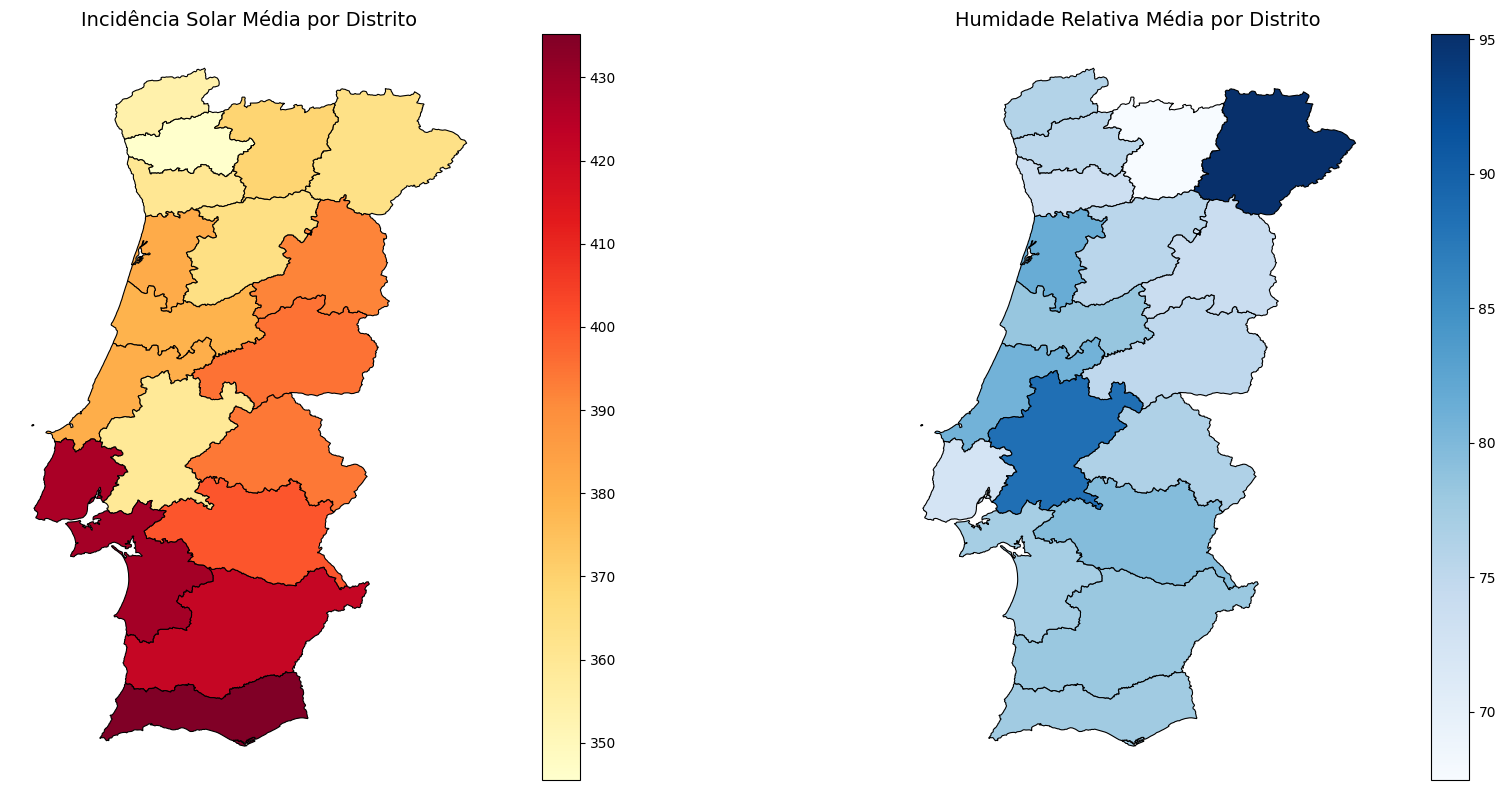

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
import time

# Configurações das APIs
USERNAME = "leonorsramos"
VISUAL_CROSSING_API_KEY = "JTDSE99F7D9SYSJW2YFQ5EDLG"

# Carregar os dados climáticos
climate_data = pd.read_csv("dados_climaticos_distritos.csv", sep=';')

# Carregar o shapefile de Portugal
mapa_pt = gpd.read_file('./pt.json')
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})

# Criar a figura com dois subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Configuração de cores
cmap_solar = mpl.cm.YlOrRd
cmap_humidity = mpl.cm.Blues

# Normalizar valores para escala de cores
min_solar = climate_data["Radiação Solar Média (W/m²)"].min()
max_solar = climate_data["Radiação Solar Média (W/m²)"].max()
norm_solar = mpl.colors.Normalize(vmin=min_solar, vmax=max_solar)

min_humidity = climate_data["Humidade Relativa Média (%)"].min()
max_humidity = climate_data["Humidade Relativa Média (%)"].max()
norm_humidity = mpl.colors.Normalize(vmin=min_humidity, vmax=max_humidity)

# Função para plotar cada mapa
def plot_map(ax, data_column, title, cmap, norm):
    mapa_data = mapa_pt.merge(climate_data, on='Distrito', how='left')
    mapa_data.plot(column=data_column, cmap=cmap, linewidth=0.8, edgecolor='black', legend=True, ax=ax, norm=norm)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

# Gerar os mapas lado a lado
plot_map(axes[0], "Radiação Solar Média (W/m²)", "Incidência Solar Média por Distrito", cmap_solar, norm_solar)
plot_map(axes[1], "Humidade Relativa Média (%)", "Humidade Relativa Média por Distrito", cmap_humidity, norm_humidity)

# Ajustar layout
plt.tight_layout()
plt.show()